## 1st TEST

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

### DATASET PREPARATION

In [3]:
# Load datasets
df = pd.read_csv("dataset/drugsCOM_raw.csv")

print(f"\nCombined dataframe shape: {df.shape}")

df.head()


Combined dataframe shape: (215063, 8)


,Unnamed: 0,uniqueID,drugName,condition,review,rating,date,usefulCount
0,0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [4]:
df.dtypes

Unnamed: 0      int64
uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

In [5]:
# Count words for review
review_lengths = df['review'].apply(lambda x: len(x.split()))
review_mean_lenth = review_lengths.mean()
review_quantile_95 = review_lengths.quantile(0.95)
review_max_length = review_lengths.max()

print(f"Average length: {review_mean_lenth:.2f}")
print(f"95th percentile: {review_quantile_95:.2f}")
print(f"Max length: {review_max_length}")

Average length: 84.68
95th percentile: 146.00
Max length: 1894


When training a transformer model like RoBERTa, limiting the text length to a specific threshold (such as 256 words) is a strategic decision based on two main factors:

1. Model constraints (RoBERTa has a hard limit of 512 tokens)

2. Computational efficiency

In [6]:
# Add a feature to capture the number of words of the review
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

# Filter to mantain only reviews <= 256 words 
df_filtered = df[df['review_length'] <= 256].copy()

# Verify how many samples remain
print(f"Original samples: {len(df)}")
print(f"Samples after filtering: {len(df_filtered)}")
print(f"Deleted samples: {len(df) - len(df_filtered)}")

Original samples: 215063
Samples after filtering: 214864
Deleted samples: 199


In [7]:
df_filtered['rating'].value_counts()

rating
10    67928
9     36674
1     28876
8     25033
7     12541
5     10719
2      9256
3      8714
6      8457
4      6666
Name: count, dtype: int64

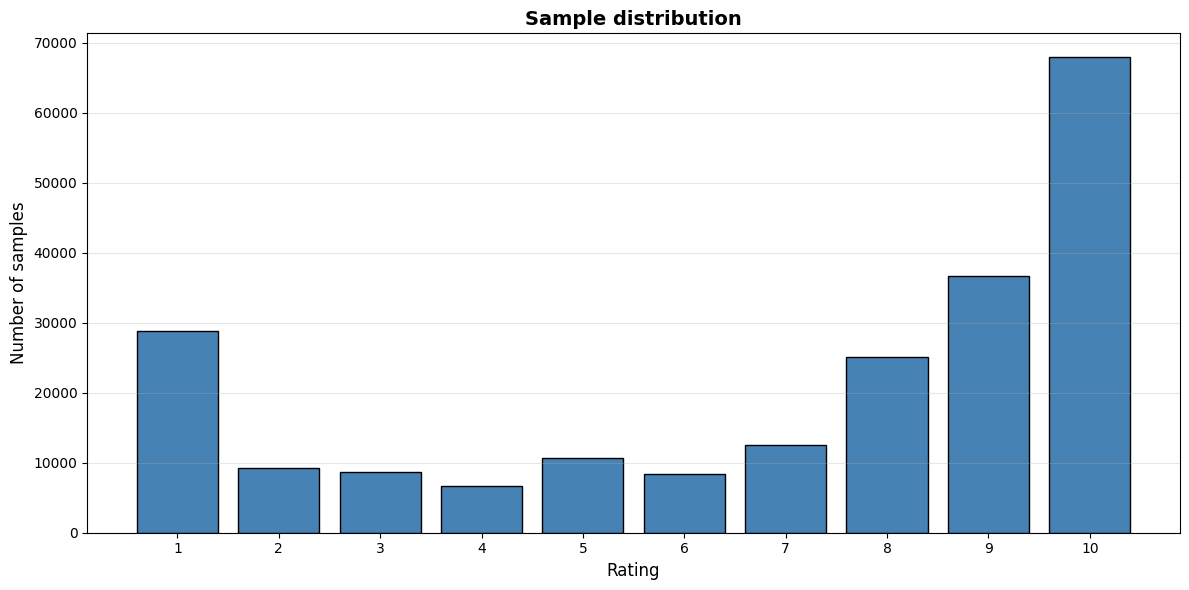

In [12]:
import matplotlib.pyplot as plt

# Get rating counts
rating_counts = df_filtered['rating'].value_counts().sort_index()

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of samples', fontsize=12)
plt.title('Sample distribution', fontsize=14, fontweight='bold')
plt.xticks(rating_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Divide the dataset into 3 buckets:
- bad < 4
- 4 <= medium <= 7
- good > 7

In [9]:
bins = [0, 4, 8, 11]
labels = ['bad', 'medium', 'good']

df_filtered['label'] = pd.cut(df_filtered['rating'], bins=bins, labels=labels, right=False, include_lowest=True)

# Verify the ditribution
counts = df_filtered['label'].value_counts()
print(f"The label ditribution is : \n{counts}")

# Identify the label ith the lowest value count
min_label = counts.idxmin()
min_value = counts.min()

print(f"\nThe label ith the lowest samples is: '{min_label}' with {min_value} counts.")

The label ditribution is : 
label
good      129635
bad        46846
medium     38383
Name: count, dtype: int64

The label ith the lowest samples is: 'medium' with 38383 counts.


In [10]:
# Under-sample categories to match the minority class
df_balanced = pd.concat([
    group.sample(n=min_value, random_state=42)
    for _, group in df_filtered.groupby('label', observed=True)
]).reset_index(drop=True)

df_balanced.to_csv("dataset/drugsCOM_balanced.csv", index=False)

# Verify the result
print("New class distribution:")
print(df_balanced['label'].value_counts())
df_balanced.head()

New class distribution:
label
bad       38383
medium    38383
good      38383
Name: count, dtype: int64


,Unnamed: 0,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,label
0,28765,144950,Etonogestrel,Birth Control,"""I got this put in at the beginning of Decemeb...",1,27-Dec-15,4,43,bad
1,9923,20161,Macrobid,Bladder Infection,"""Felt suddenly spaced-out, sat down at my work...",1,26-Feb-16,13,38,bad
2,123377,221518,Makena,Premature Lab,"""In May 2017 My doctor started me on these sho...",1,15-Nov-17,0,35,bad
3,124060,199038,Depo-Provera,Abnormal Uterine Bleeding,"""Stay as far away as possible from this medici...",1,23-Feb-16,28,120,bad
4,20431,219649,Taytulla,Birth Control,"""I took this pill for approximately 5 days and...",1,25-Jun-17,4,88,bad


In [11]:
# Define Features (X) and Target (y)
X = df_balanced['review']
y = df_balanced['label']

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y          # keep the 1:1:1 ratio is kept in both sets
)

# Verify the results
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

print("\nClass distribution in Training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in Test set:")
print(y_test.value_counts(normalize=True))

Training set size: 92119
Test set size: 23030

Class distribution in Training set:
label
bad       0.333341
medium    0.333330
good      0.333330
Name: proportion, dtype: float64

Class distribution in Test set:
label
medium    0.333348
good      0.333348
bad       0.333304
Name: proportion, dtype: float64


### MODEL ARCHITECTURE (a partir d'aqui està fet per Gemini)

### TRANING

### VALIDATION